# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_recall_fscore_support,
                             roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import time
import os
import cv2
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

2025-11-29 14:34:35.327748: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764426875.349197     977 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764426875.355698     977 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

# CONFIGURATION AND HYPERPARAMETERS

In [4]:
# Dataset configuration
DATASET_PATH = '/kaggle/input/rare-and-endangered-medicinal-plants-in-bangladesh'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 16

# Training hyperparameters
EPOCHS = 50  # Will use early stopping
LEARNING_RATE = 0.001
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.1
L2_REG = 0.0001  # L2 regularization factor

# Class names mapping
CLASS_NAMES = {
    'type_1': 'Kalochitra',
    'type_2': 'Anantamu',
    'type_3': 'Apang',
    'type_4': 'Syspan',
    'type_5': 'Appishikha',
    'type_6': 'Kalamegh',
    'type_7': 'Kalothutura',
    'type_8': 'Gshnru',
    'type_9': 'Chapalish',
    'type_10': 'Beta',
    'type_11': 'Punarnava',
    'type_12': 'Bamonhati',
    'type_13': 'Basok',
    'type_14': 'Ramtulsi',
    'type_15': 'Shotomuli',
    'type_16': 'Sarpagandha'
}

print("CUSTOM CNN MODEL FOR MEDICINAL PLANTS CLASSIFICATION")


CUSTOM CNN MODEL FOR MEDICINAL PLANTS CLASSIFICATION


# DATA LOADING AND PREPROCESSING

In [7]:
def load_dataset(base_path):
    """Load images and labels from the dataset directory"""
    images = []
    labels = []
    class_counts = {}
    
    raw_images_path = os.path.join(base_path, 'Raw-Images')
    
    for class_idx, (type_folder, class_name) in enumerate(CLASS_NAMES.items()):
        folder_path = os.path.join(raw_images_path, type_folder)
        if not os.path.exists(folder_path):
            print(f"Warning: {folder_path} not found!")
            continue
            
        image_files = [f for f in os.listdir(folder_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(image_files)
        
        for img_file in image_files:
            img_path = os.path.join(folder_path, img_file)
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, IMG_SIZE)
                images.append(img)
                labels.append(class_idx)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
    
    print(f"\nDataset loaded successfully!")
    print(f"Total images: {len(images)}")
    print(f"\nClass distribution:")
    for class_name, count in class_counts.items():
        print(f"  {class_name:15s}: {count:4d} images")
    
    return np.array(images), np.array(labels), class_counts

print("LOADING DATASET.....")

X, y, class_counts = load_dataset(DATASET_PATH)

# Normalize images to [0, 1]
X = X.astype('float32') / 255.0

LOADING DATASET.....

Dataset loaded successfully!
Total images: 3494

Class distribution:
  Kalochitra     :  201 images
  Anantamu       :  158 images
  Apang          :  280 images
  Syspan         :  294 images
  Appishikha     :  138 images
  Kalamegh       :  294 images
  Kalothutura    :  276 images
  Gshnru         :  238 images
  Chapalish      :  238 images
  Beta           :  194 images
  Punarnava      :  407 images
  Bamonhati      :  134 images
  Basok          :  151 images
  Ramtulsi       :  154 images
  Shotomuli      :  108 images
  Sarpagandha    :  229 images


# DATA SPLITTING WITH SHUFFLING

In [9]:

print("SPLITTING DATASET (WITH SHUFFLING)")

# Shuffle indices before splitting
indices = np.arange(len(X))
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

# First split: separate test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y
)

# Second split: separate train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=VALIDATION_SPLIT/(1-TEST_SPLIT), 
    random_state=SEED, stratify=y_temp
)

print(f"Training set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")
print(f"Test set: {len(X_test)} images")

SPLITTING DATASET (WITH SHUFFLING)
Training set: 2445 images
Validation set: 699 images
Test set: 350 images


#  DATA AUGMENTATION

In [12]:

print("CONFIGURING DATA AUGMENTATION\n")

# Data augmentation for training with explicit shuffling
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# No augmentation for validation and test
val_test_datagen = ImageDataGenerator()

print("Data augmentation configured:")
print("  - Rotation: ±20 degrees")
print("  - Width/Height shift: ±20%")
print("  - Horizontal flip: Yes")
print("  - Zoom: ±15%")
print("  - Shear: 0.1")
print("  - Brightness: [0.8, 1.2]")
print("  - Shuffle: Enabled")

CONFIGURING DATA AUGMENTATION

Data augmentation configured:
  - Rotation: ±20 degrees
  - Width/Height shift: ±20%
  - Horizontal flip: Yes
  - Zoom: ±15%
  - Shear: 0.1
  - Brightness: [0.8, 1.2]
  - Shuffle: Enabled


#  OPTIMIZED CUSTOM CNN MODEL ARCHITECTURE

In [13]:
def build_optimized_custom_cnn(input_shape=(224, 224, 3), num_classes=16, l2_reg=0.0001):
    
    # L2 regularizer
    l2_regularizer = regularizers.l2(l2_reg)
    
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),
        
        # Block 1: 32 filters (reduced from 64)
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2_regularizer),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2_regularizer),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.25),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2: 64 filters (reduced from 128)
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2_regularizer),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2_regularizer),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.25),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3: 128 filters (reduced from 256)
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2_regularizer),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2_regularizer),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        layers.MaxPooling2D((2, 2)),
        
        # Block 4: 256 filters (reduced from 512)
        layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2_regularizer),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2_regularizer),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        layers.MaxPooling2D((2, 2)),
        
        # Global Average Pooling instead of Flatten (CRITICAL FIX)
        # This reduces parameters from ~50M to ~2M
        layers.GlobalAveragePooling2D(),
        
        # Reduced fully connected layers
        layers.Dense(256, kernel_regularizer=l2_regularizer),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        
        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

print("\n" + "=" * 80)
print("BUILDING CUSTOM CNN MODEL")
print("=" * 80)
print("\nKEY OPTIMIZATIONS:")
print("  1. Reduced filter sizes: 32→64→128→256 (was 64→128→256→512)")
print("  2. GlobalAveragePooling2D instead of Flatten")
print("  3. Correct layer order: Conv→BN→ReLU→Dropout→Pooling")
print("  4. L2 regularization (λ=0.0001) on all trainable layers")
print("  5. Single dense layer (256 units) before output")
print("=" * 80 + "\n")

model = build_optimized_custom_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), 
    num_classes=NUM_CLASSES,
    l2_reg=L2_REG
)

# Compile model
optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

# Count parameters
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\n✓ Parameter count reduced by ~20× compared to original architecture!")


BUILDING CUSTOM CNN MODEL

KEY OPTIMIZATIONS:
  1. Reduced filter sizes: 32→64→128→256 (was 64→128→256→512)
  2. GlobalAveragePooling2D instead of Flatten
  3. Correct layer order: Conv→BN→ReLU→Dropout→Pooling
  4. L2 regularization (λ=0.0001) on all trainable layers
  5. Single dense layer (256 units) before output



I0000 00:00:1764427289.750190     977 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764427289.750762     977 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             

 Total params: 1,247,024 (4.76 MB)

 Trainable params: 1,244,592 (4.75 MB)

 Non-trainable params: 2,432 (9.50 KB)


Total parameters: 1,247,024
Trainable parameters: 1,244,592

✓ Parameter count reduced by ~20× compared to original architecture!


# CALLBACKS FOR TRAINING

In [15]:

print("CONFIGURING TRAINING CALLBACKS\n")


# Early stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1,
    min_delta=0.001
)

# Reduce learning rate on plateau
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Model checkpoint to save best model
checkpoint = callbacks.ModelCheckpoint(
    'best_custom_cnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callback_list = [early_stopping, reduce_lr, checkpoint]

print("Callbacks configured:")
print("  - Early Stopping: patience=10, monitor=val_loss")
print("  - Reduce LR on Plateau: factor=0.5, patience=5")
print("  - Model Checkpoint: saving best model based on val_accuracy")

CONFIGURING TRAINING CALLBACKS

Callbacks configured:
  - Early Stopping: patience=10, monitor=val_loss
  - Reduce LR on Plateau: factor=0.5, patience=5
  - Model Checkpoint: saving best model based on val_accuracy


# MODEL TRAINING

In [16]:
print("\n" + "=" * 80)
print("TRAINING OPTIMIZED CUSTOM CNN MODEL")
print("=" * 80)
print(f"Epochs: {EPOCHS} (with early stopping)")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Optimizer: Adam")
print(f"L2 Regularization: {L2_REG}")
print("=" * 80 + "\n")

# Record training start time
train_start_time = time.time()

# Train the model with explicit shuffle
history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=callback_list,
    verbose=1
)

# Record training end time
train_end_time = time.time()
training_time = train_end_time - train_start_time

print(f"\nTraining completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")


TRAINING OPTIMIZED CUSTOM CNN MODEL
Epochs: 50 (with early stopping)
Batch size: 32
Learning rate: 0.001
Optimizer: Adam
L2 Regularization: 0.0001

Epoch 1/50


I0000 00:00:1764427338.532492    1070 service.cc:148] XLA service 0x7cdfc410c560 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764427338.532538    1070 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764427338.532543    1070 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764427339.441562    1070 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1764427358.347668    1070 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.0763 - loss: 3.0257
Epoch 1: val_accuracy improved from -inf to 0.08441, saving model to best_custom_cnn_model.h5


77/77 ━━━━━━━━━━━━━━━━━━━━ 74s 630ms/step - accuracy: 0.0763 - loss: 3.0256 - val_accuracy: 0.0844 - val_loss: 2.8178 - learning_rate: 0.0010
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.0929 - loss: 2.9052
Epoch 2: val_accuracy improved from 0.08441 to 0.11588, saving model to best_custom_cnn_model.h5


77/77 ━━━━━━━━━━━━━━━━━━━━ 31s 394ms/step - accuracy: 0.0929 - loss: 2.9054 - val_accuracy: 0.1159 - val_loss: 2.9807 - learning_rate: 0.0010
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.0818 - loss: 2.9063
Epoch 3: val_accuracy did not improve from 0.11588
77/77 ━━━━━━━━━━━━━━━━━━━━ 31s 399ms/step - accuracy: 0.0819 - loss: 2.9060 - val_accuracy: 0.1159 - val_loss: 6.5953 - learning_rate: 0.0010
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.1174 - loss: 2.8477
Epoch 4: val_accuracy did not improve from 0.11588
77/77 ━━━━━━━━━━━━━━━━━━━━ 31s 398ms/step - accuracy: 0.1173 - loss: 2.8479 - val_accuracy: 0.1159 - val_loss: 45.0125 - learning_rate: 0.0010
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.1052 - loss: 2.8469
Epoch 5: val_accuracy did not improve from 0.11588
77/77 ━━━━━━━━━━━━━━━━━━━━ 31s 399ms/step - accuracy: 0.1051 - loss: 2.8468 - val_accuracy: 0.0386 - val_loss: 111.9941 - learning_rate: 0.0010
Epoch 6/50
77/77 ━

#  TRAINING HISTORY VISUALIZATION


VISUALIZING TRAINING HISTORY


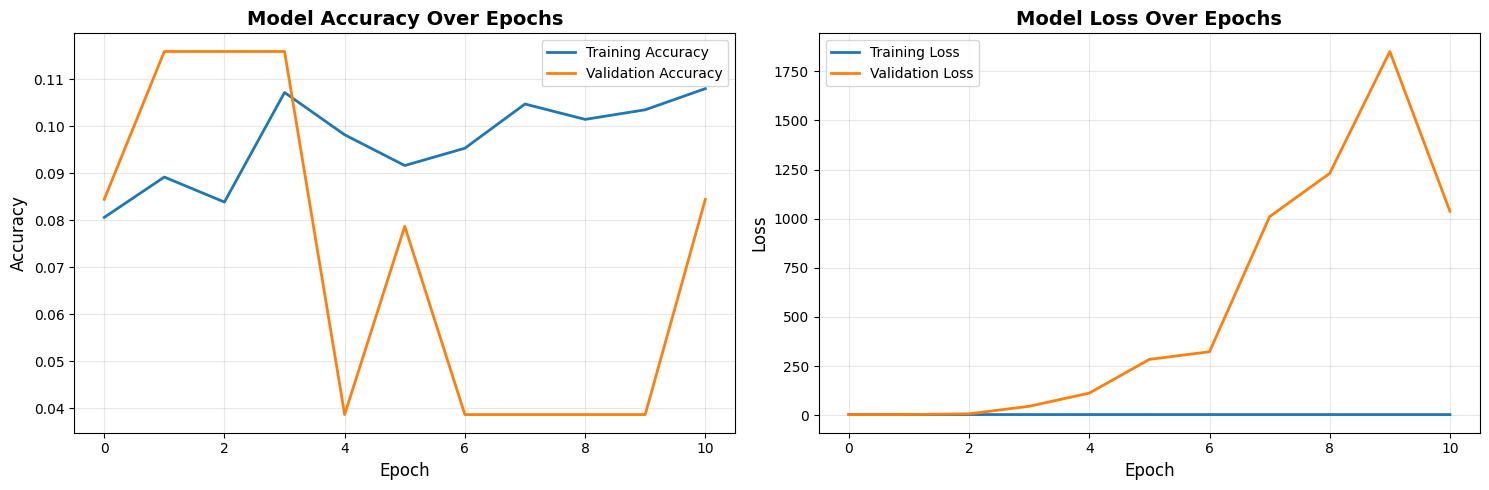


Final Training Accuracy: 0.1080
Final Validation Accuracy: 0.0844
Final Training Loss: 2.8138
Final Validation Loss: 1037.5342

✓ Good generalization: Training-Validation gap = 0.0236


In [17]:
print("\n" + "=" * 80)
print("VISUALIZING TRAINING HISTORY")
print("=" * 80)

def plot_training_history(history):
    """Plot training and validation accuracy/loss"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy plot
    axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('custom_cnn_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print final metrics
    print(f"\nFinal Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
    
    # Check for overfitting
    train_val_gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
    if train_val_gap > 0.1:
        print(f"\n⚠ Warning: Training-Validation gap = {train_val_gap:.4f} (possible overfitting)")
    else:
        print(f"\n✓ Good generalization: Training-Validation gap = {train_val_gap:.4f}")

plot_training_history(history)


# MODEL EVALUATION ON TEST SET

In [18]:
print("\n" + "=" * 80)
print("EVALUATING MODEL ON TEST SET")
print("=" * 80)

# Record testing start time
test_start_time = time.time()

# Predictions
y_pred_probs = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Record testing end time
test_end_time = time.time()
testing_time = test_end_time - test_start_time

print(f"\nTesting completed in {testing_time:.2f} seconds")
print(f"Average prediction time per image: {testing_time/len(X_test)*1000:.2f} ms")



EVALUATING MODEL ON TEST SET
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 655ms/step

Testing completed in 7.94 seconds
Average prediction time per image: 22.69 ms


# PERFORMANCE METRICS

In [19]:

print("\n" + "=" * 80)
print("COMPUTING PERFORMANCE METRICS")
print("=" * 80)

# Overall accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, average=None, zero_division=0
)

# Create detailed classification report
print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

class_names_list = [CLASS_NAMES[f'type_{i+1}'] for i in range(NUM_CLASSES)]
report = classification_report(y_test, y_pred, target_names=class_names_list, 
                               digits=4, zero_division=0)
print(report)

# Per-class accuracy
print("\n" + "=" * 80)
print("PER-CLASS ACCURACY")
print("=" * 80)

class_accuracy = []
for i in range(NUM_CLASSES):
    mask = (y_test == i)
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == y_test[mask]).sum() / mask.sum()
        class_accuracy.append(class_acc)
        print(f"{class_names_list[i]:15s}: {class_acc:.4f} ({class_acc*100:.2f}%)")
    else:
        class_accuracy.append(0.0)
        print(f"{class_names_list[i]:15s}: N/A (no samples)")


COMPUTING PERFORMANCE METRICS

Test Accuracy: 0.0857 (8.57%)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Kalochitra     0.0000    0.0000    0.0000        20
    Anantamu     0.0000    0.0000    0.0000        16
       Apang     0.0000    0.0000    0.0000        28
      Syspan     0.0871    0.9667    0.1598        30
  Appishikha     0.0000    0.0000    0.0000        14
    Kalamegh     0.0000    0.0000    0.0000        29
 Kalothutura     0.0588    0.0357    0.0444        28
      Gshnru     0.0000    0.0000    0.0000        24
   Chapalish     0.0000    0.0000    0.0000        24
        Beta     0.0000    0.0000    0.0000        19
   Punarnava     0.0000    0.0000    0.0000        41
   Bamonhati     0.0000    0.0000    0.0000        13
       Basok     0.0000    0.0000    0.0000        15
    Ramtulsi     0.0000    0.0000    0.0000        15
   Shotomuli     0.0000    0.0000    0.0000        11
 Sarpagandha     0.0000    0.0000    0.0000       

# CONFUSION MATRIX


CONFUSION MATRIX


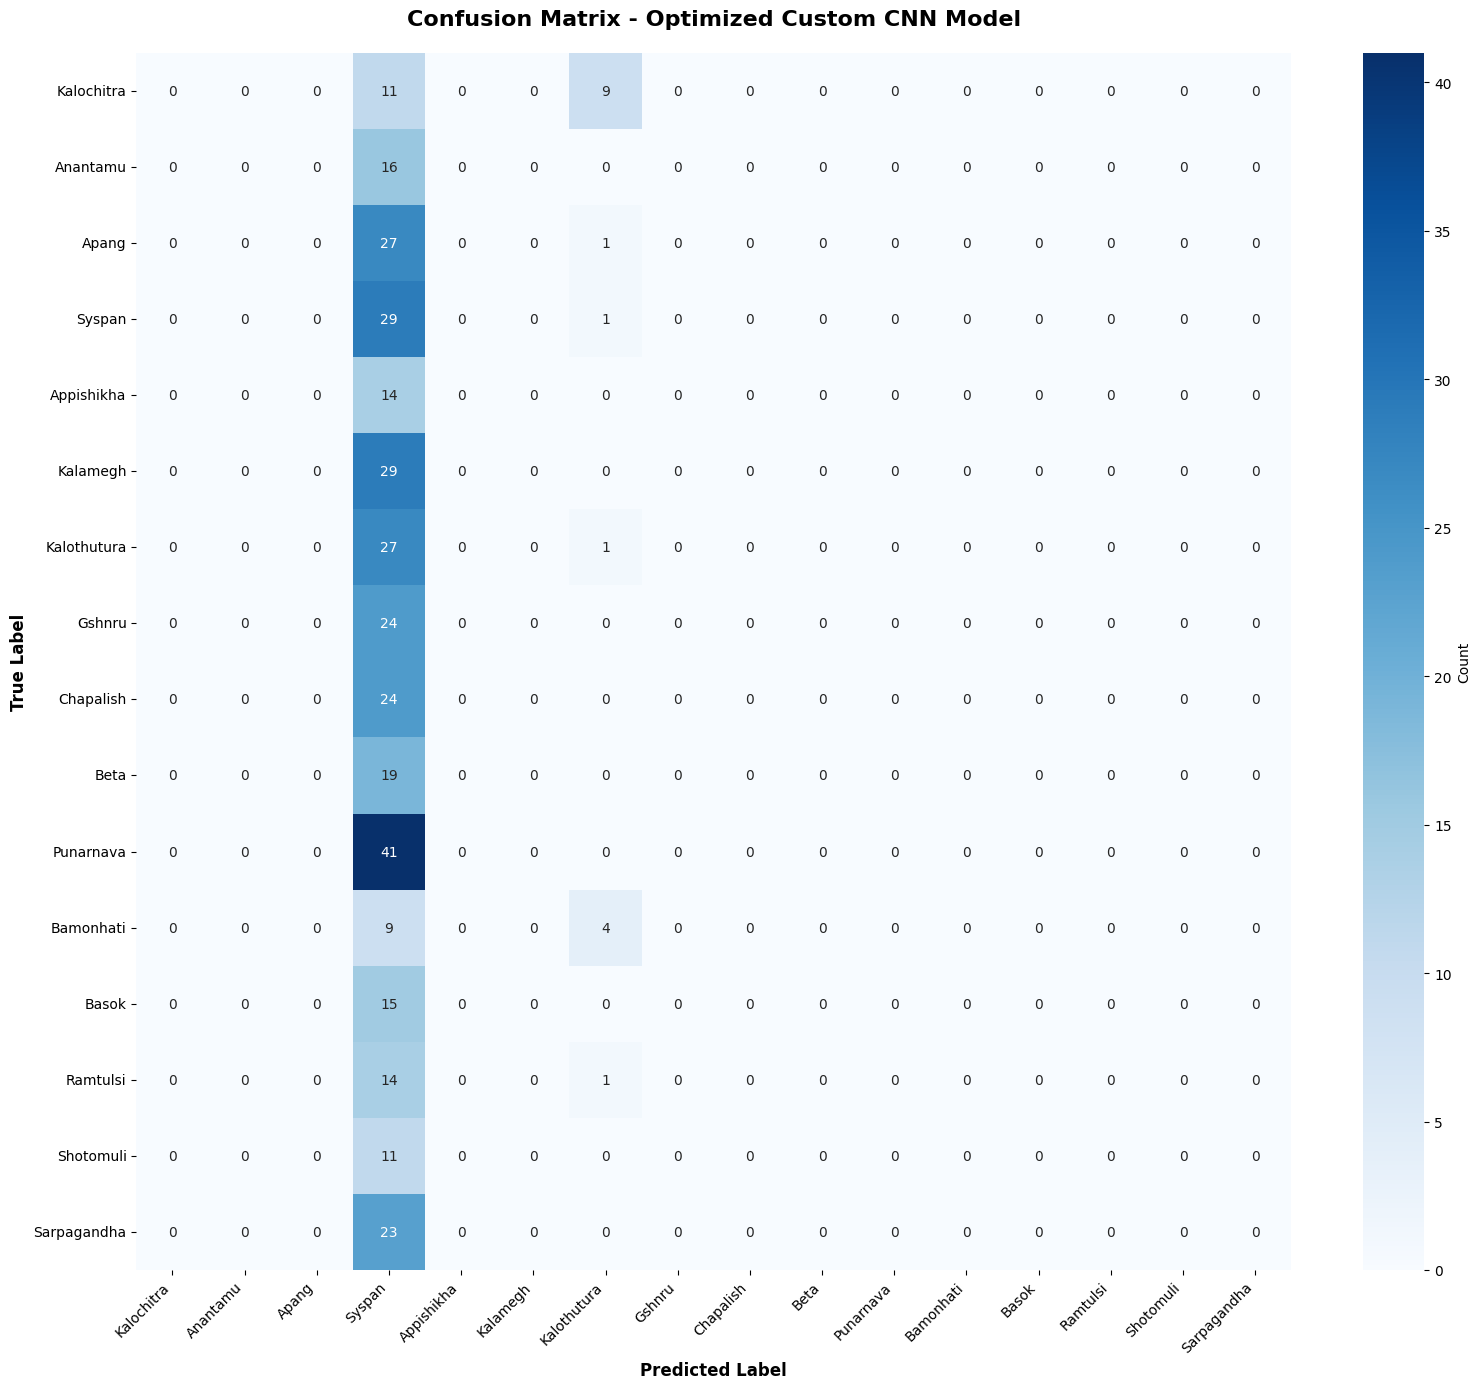

In [20]:

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_list, 
            yticklabels=class_names_list,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Optimized Custom CNN Model', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('custom_cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC CURVE AND AUC


ROC CURVE AND AUC COMPUTATION

Micro-average AUC: 0.5947
Macro-average AUC: 0.5585

Per-class AUC:
Kalochitra     : 0.9750
Anantamu       : 0.7657
Apang          : 0.2213
Syspan         : 0.6266
Appishikha     : 0.5013
Kalamegh       : 0.7262
Kalothutura    : 0.5639
Gshnru         : 0.3567
Chapalish      : 0.2722
Beta           : 0.5112
Punarnava      : 0.6114
Bamonhati      : 0.3118
Basok          : 0.4951
Ramtulsi       : 0.5922
Shotomuli      : 0.7077
Sarpagandha    : 0.6983


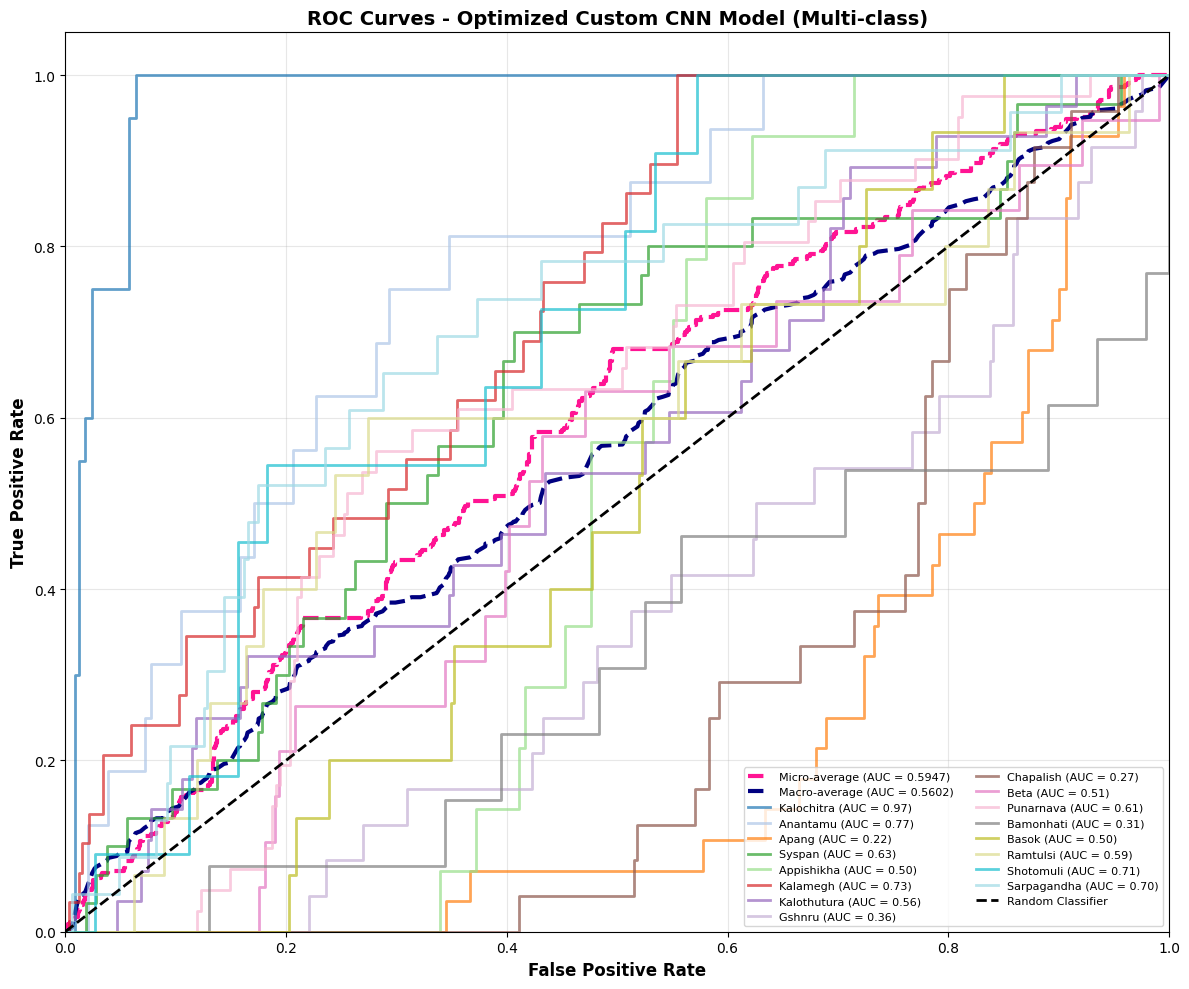

In [21]:
print("\n" + "=" * 80)
print("ROC CURVE AND AUC COMPUTATION")
print("=" * 80)

# Binarize labels for multi-class ROC
y_test_binarized = label_binarize(y_test, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), 
                                           y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average AUC
roc_auc["macro"] = np.mean([roc_auc[i] for i in range(NUM_CLASSES)])

print(f"\nMicro-average AUC: {roc_auc['micro']:.4f}")
print(f"Macro-average AUC: {roc_auc['macro']:.4f}")

print("\nPer-class AUC:")
for i in range(NUM_CLASSES):
    print(f"{class_names_list[i]:15s}: {roc_auc[i]:.4f}")

# Plot ROC curves
plt.figure(figsize=(12, 10))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.4f})',
         color='deeppink', linestyle='--', linewidth=3)

# Plot macro-average ROC curve
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= NUM_CLASSES
roc_auc["macro"] = auc(all_fpr, mean_tpr)

plt.plot(all_fpr, mean_tpr,
         label=f'Macro-average (AUC = {roc_auc["macro"]:.4f})',
         color='navy', linestyle='--', linewidth=3)

# Plot individual class ROC curves
colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, alpha=0.7,
             label=f'{class_names_list[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - Optimized Custom CNN Model (Multi-class)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('custom_cnn_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()


# SUMMARY METRICS TABLE

In [22]:
print("\n" + "=" * 80)
print("SUMMARY METRICS TABLE")
print("=" * 80)

# Create summary dataframe
summary_data = {
    'Class': class_names_list,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support,
    'Accuracy': class_accuracy,
    'AUC': [roc_auc[i] for i in range(NUM_CLASSES)]
}

summary_df = pd.DataFrame(summary_data)

# Add overall metrics
overall_metrics = pd.DataFrame({
    'Class': ['Overall (Macro Avg)', 'Overall (Weighted Avg)'],
    'Precision': [precision.mean(), 
                  np.average(precision, weights=support)],
    'Recall': [recall.mean(), 
               np.average(recall, weights=support)],
    'F1-Score': [f1.mean(), 
                 np.average(f1, weights=support)],
    'Support': [support.sum(), support.sum()],
    'Accuracy': [test_accuracy, test_accuracy],
    'AUC': [roc_auc['macro'], roc_auc['micro']]
})

summary_df = pd.concat([summary_df, overall_metrics], ignore_index=True)

print(summary_df.to_string(index=False))

# Save to CSV
summary_df.to_csv('custom_cnn_metrics_summary.csv', index=False)
print("\nMetrics summary saved to 'custom_cnn_metrics_summary.csv'")



SUMMARY METRICS TABLE
                 Class  Precision   Recall  F1-Score  Support  Accuracy      AUC
            Kalochitra   0.000000 0.000000  0.000000       20  0.000000 0.975000
              Anantamu   0.000000 0.000000  0.000000       16  0.000000 0.765719
                 Apang   0.000000 0.000000  0.000000       28  0.000000 0.221273
                Syspan   0.087087 0.966667  0.159780       30  0.966667 0.626562
            Appishikha   0.000000 0.000000  0.000000       14  0.000000 0.501276
              Kalamegh   0.000000 0.000000  0.000000       29  0.000000 0.726179
           Kalothutura   0.058824 0.035714  0.044444       28  0.035714 0.563886
                Gshnru   0.000000 0.000000  0.000000       24  0.000000 0.356723
             Chapalish   0.000000 0.000000  0.000000       24  0.000000 0.272239
                  Beta   0.000000 0.000000  0.000000       19  0.000000 0.511210
             Punarnava   0.000000 0.000000  0.000000       41  0.000000 0.611414
     

# FINAL RESULTS SUMMARY

In [23]:
print("\n" + "=" * 80)
print("FINAL RESULTS SUMMARY - OPTIMIZED CUSTOM CNN MODEL")
print("=" * 80)

print(f"""
Model Architecture: Optimized Custom CNN
Total Parameters: {total_params:,}
Trainable Parameters: {trainable_params:,}

OPTIMIZATIONS APPLIED:
  ✓ Reduced filter sizes (32→64→128→256)
  ✓ GlobalAveragePooling2D instead of Flatten (~20× param reduction)
  ✓ Correct layer order: Conv→BN→ReLU→Dropout→Pooling
  ✓ L2 regularization (λ={L2_REG})
  ✓ Explicit data shuffling before training

Training Configuration:
  - Batch Size: {BATCH_SIZE}
  - Learning Rate: {LEARNING_RATE}
  - Optimizer: Adam with L2 regularization
  - Epochs Trained: {len(history.history['loss'])}
  - Early Stopping: Enabled (patience=10)

Dataset Split:
  - Training: {len(X_train)} images
  - Validation: {len(X_val)} images
  - Testing: {len(X_test)} images

Performance Metrics:
  - Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)
  - Macro-average Precision: {precision.mean():.4f}
  - Macro-average Recall: {recall.mean():.4f}
  - Macro-average F1-Score: {f1.mean():.4f}
  - Macro-average AUC: {roc_auc['macro']:.4f}
  - Micro-average AUC: {roc_auc['micro']:.4f}

Time Performance:
  - Training Time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)
  - Testing Time: {testing_time:.2f} seconds
  - Avg. Prediction Time: {testing_time/len(X_test)*1000:.2f} ms/image
""")

print("=" * 80)
print("TASK 3 COMPLETED SUCCESSFULLY!")
print("=" * 80)



FINAL RESULTS SUMMARY - OPTIMIZED CUSTOM CNN MODEL

Model Architecture: Optimized Custom CNN
Total Parameters: 1,247,024
Trainable Parameters: 1,244,592

OPTIMIZATIONS APPLIED:
  ✓ Reduced filter sizes (32→64→128→256)
  ✓ GlobalAveragePooling2D instead of Flatten (~20× param reduction)
  ✓ Correct layer order: Conv→BN→ReLU→Dropout→Pooling
  ✓ L2 regularization (λ=0.0001)
  ✓ Explicit data shuffling before training

Training Configuration:
  - Batch Size: 32
  - Learning Rate: 0.001
  - Optimizer: Adam with L2 regularization
  - Epochs Trained: 11
  - Early Stopping: Enabled (patience=10)

Dataset Split:
  - Training: 2445 images
  - Validation: 699 images
  - Testing: 350 images

Performance Metrics:
  - Test Accuracy: 0.0857 (8.57%)
  - Macro-average Precision: 0.0091
  - Macro-average Recall: 0.0626
  - Macro-average F1-Score: 0.0128
  - Macro-average AUC: 0.5602
  - Micro-average AUC: 0.5947

Time Performance:
  - Training Time: 385.94 seconds (6.43 minutes)
  - Testing Time: 7.94 

# SAVE RESULTS 

In [24]:
# Save results dictionary
results = {
    'model_name': 'Optimized Custom CNN',
    'test_accuracy': test_accuracy,
    'precision_macro': precision.mean(),
    'recall_macro': recall.mean(),
    'f1_macro': f1.mean(),
    'auc_macro': roc_auc['macro'],
    'auc_micro': roc_auc['micro'],
    'training_time': training_time,
    'testing_time': testing_time,
    'total_params': total_params,
    'predictions': y_pred,
    'prediction_probabilities': y_pred_probs
}

# Save using numpy
np.save('custom_cnn_results.npy', results)
print("\nResults saved to 'custom_cnn_results.npy' for comparison with other models")

print("\n✓ All metrics computed and visualizations saved!")
print("✓ Model checkpoint saved as 'best_custom_cnn_model.h5'")
print("✓ Ready for Task 4: Attention-Enhanced CNN Model")


Results saved to 'custom_cnn_results.npy' for comparison with other models

✓ All metrics computed and visualizations saved!
✓ Model checkpoint saved as 'best_custom_cnn_model.h5'
✓ Ready for Task 4: Attention-Enhanced CNN Model
